May return to this notebook periodically for ongoing optimization.

In [17]:
import pandas as pd

Import Round one statistics - These are basic models with no GridSearch optimization and no feature selection. 

We will average them out, see which features are least correlated with errors, and use those figures to select a new feature set.

In [18]:
df_round1_linreg = pd.read_csv('models_daily_results/Round_1_Linreg.csv')
df_round1_rfr = pd.read_csv('models_daily_results/Round_1_RFR.csv')

In [19]:
dfs_to_merge = df_round1_linreg, df_round1_rfr

In [20]:
df_round1_rfr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct,pred_next_close_change_pct,pred_error,abs_pred_error,directionally_correct
0,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,37.78,37.15,0.016958,35.71,-2.28,-6.001579,-6.03,-2.842064e-02,2.842064e-02,1
1,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,37.99,37.78,0.005558,36.49,0.78,2.184262,2.16,-2.426211e-02,2.426211e-02,1
2,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,35.71,37.99,-0.060016,36.24,-0.25,-0.685119,-0.69,-4.880789e-03,4.880789e-03,1
3,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,36.49,35.71,0.021843,36.00,-0.24,-0.662252,-0.66,2.251656e-03,2.251656e-03,1
4,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,36.24,36.49,-0.006851,35.91,-0.09,-0.250000,-0.25,9.436896e-15,9.436896e-15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99245,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,123.54,123.78,-0.001939,126.23,0.74,0.589688,0.59,3.115786e-04,3.115786e-04,1
99246,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,125.49,123.54,0.015784,125.98,-0.25,-0.198051,-0.20,-1.948824e-03,1.948824e-03,1
99247,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,126.23,125.49,0.005897,126.41,0.43,0.341324,0.34,-1.324020e-03,1.324020e-03,1
99248,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,125.98,126.23,-0.001981,125.82,-0.59,-0.466735,-0.47,-3.264773e-03,3.264773e-03,1


In [21]:
df_round1_rfr.columns

Index(['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap',
       'transactions', 'close_vs_open_pct', 'daily_high_vs_low_pct',
       'prev_day_return', 'SMA10', 'SMA20', 'SMA50', 'SMA100', 'RSI', 'MACD',
       'MACD_signal', 'MACD_hist', 'rolling_volatility', 'close_lag1',
       'close_lag2', 'return_lag1', 'next_close', 'next_close_change',
       'next_close_change_pct', 'pred_next_close_change_pct', 'pred_error',
       'abs_pred_error', 'directionally_correct'],
      dtype='object')

In [1]:
from functools import reduce
import pandas as pd

# Load datasets
df_round1_linreg = pd.read_csv('models_daily_results/Round_1_Linreg.csv')
df_round1_rfr = pd.read_csv('models_daily_results/Round_1_RFR.csv')
df_round1_svr = pd.read_csv('models_daily_results/Round_1_SVR.csv')
df_round1_xgbr = pd.read_csv('models_daily_results/Round_1_XGBR.csv')


# Create dictionary of dataframes to merge
dfs_to_merge = {
    "RFR": df_round1_rfr,
    "Linreg": df_round1_linreg,
    "SVR": df_round1_svr,
    "XGBR": df_round1_xgbr
}

merge_cols = ["timestamp", "ticker"]

pred_cols = [
    "pred_next_close",
    "pred_next_close_change_pct",
    "pred_error",
    "abs_pred_error",
    "directionally_correct",
]

def prepare_model_df(df, model_name):

    df = df.copy()

    rename_map = {
        col: f"{model_name}_{col}"
        for col in pred_cols
        if col in df.columns
    }

    df = df.rename(columns=rename_map)

    model_cols = list(rename_map.values())

    return df[merge_cols + model_cols]

# Use first dataframe as base
first_key = list(dfs_to_merge.keys())[0]

base_df = dfs_to_merge[first_key].copy()

# Remove original un-prefixed prediction columns
base_df = base_df.drop(
    columns=[col for col in pred_cols if col in base_df.columns]
)

# Create model-specific dfs
model_dfs = [
    prepare_model_df(df, model_name)
    for model_name, df in dfs_to_merge.items()
]

# Merge everything
merged_results = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=merge_cols,
        how="inner"
    ),
    [base_df] + model_dfs
)

print("Merged shape:", merged_results.shape)

merged_results.head()

Merged shape: (99250, 43)


,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,Linreg_abs_pred_error,Linreg_directionally_correct,SVR_pred_next_close_change_pct,SVR_pred_error,SVR_abs_pred_error,SVR_directionally_correct,XGBR_pred_next_close_change_pct,XGBR_pred_error,XGBR_abs_pred_error,XGBR_directionally_correct
0,2025-01-02,AA,38.165,39.040,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,4.801579,1,0.02,6.021579,6.021579,0,-5.91,0.091580,0.091580,1
1,2025-01-03,AA,37.950,37.950,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,1.804262,1,0.04,-2.144262,2.144262,1,1.86,-0.324262,0.324262,1
2,2025-01-06,AA,36.000,37.075,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,0.685119,0,0.04,0.725119,0.725119,0,-0.63,0.055119,0.055119,1
3,2025-01-07,AA,36.890,37.300,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,0.552252,1,0.03,0.692252,0.692252,0,-0.63,0.032252,0.032252,1
4,2025-01-08,AA,35.780,36.030,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,0.250000,0,0.03,0.280000,0.280000,0,-0.23,0.020000,0.020000,1


In [2]:
# Find all matching model result columns
pred_error_cols = [
    col for col in merged_results.columns
    if col.endswith("_pred_error")
]

abs_pred_error_cols = [
    col for col in merged_results.columns
    if col.endswith("_abs_pred_error")
]

direction_cols = [
    col for col in merged_results.columns
    if col.endswith("_directionally_correct")
]

# Create aggregate dataframe
model_row_aggs = merged_results.copy()

model_row_aggs["avg_pred_error"] = model_row_aggs[pred_error_cols].mean(axis=1)

model_row_aggs["avg_abs_pred_error"] = model_row_aggs[abs_pred_error_cols].mean(axis=1)

model_row_aggs["pct_directionally_correct"] = (
    model_row_aggs[direction_cols].mean(axis=1) * 100
)

model_row_aggs

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,SVR_pred_error,SVR_abs_pred_error,SVR_directionally_correct,XGBR_pred_next_close_change_pct,XGBR_pred_error,XGBR_abs_pred_error,XGBR_directionally_correct,avg_pred_error,avg_abs_pred_error,pct_directionally_correct
0,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,6.021579,6.021579,0,-5.91,0.091580,0.091580,1,2.728685,2.735790,75.0
1,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,-2.144262,2.144262,1,1.86,-0.324262,0.324262,1,0.000000,1.074262,100.0
2,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,0.725119,0.725119,0,-0.63,0.055119,0.055119,1,0.366339,0.367560,50.0
3,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,0.692252,0.692252,0,-0.63,0.032252,0.032252,1,0.319752,0.319752,75.0
4,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,0.280000,0.280000,0,-0.23,0.020000,0.020000,1,0.137500,0.137500,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99245,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,-0.569688,0.569688,1,0.61,0.020312,0.020312,1,0.005156,0.192500,100.0
99246,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,0.228051,0.228051,0,-0.16,0.038051,0.038051,1,0.081038,0.081526,75.0
99247,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,-0.311324,0.311324,1,0.43,0.088676,0.088676,1,0.022169,0.133162,100.0
99248,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,0.496735,0.496735,0,-0.44,0.026735,0.026735,1,0.165051,0.165868,75.0


In [4]:
merged_results.columns

Index(['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap',
       'transactions', 'close_vs_open_pct', 'daily_high_vs_low_pct',
       'prev_day_return', 'SMA10', 'SMA20', 'SMA50', 'SMA100', 'RSI', 'MACD',
       'MACD_signal', 'MACD_hist', 'rolling_volatility', 'close_lag1',
       'close_lag2', 'return_lag1', 'next_close', 'next_close_change',
       'next_close_change_pct', 'RFR_pred_next_close_change_pct',
       'RFR_pred_error', 'RFR_abs_pred_error', 'RFR_directionally_correct',
       'Linreg_pred_next_close_change_pct', 'Linreg_pred_error',
       'Linreg_abs_pred_error', 'Linreg_directionally_correct',
       'SVR_pred_next_close_change_pct', 'SVR_pred_error',
       'SVR_abs_pred_error', 'SVR_directionally_correct',
       'XGBR_pred_next_close_change_pct', 'XGBR_pred_error',
       'XGBR_abs_pred_error', 'XGBR_directionally_correct'],
      dtype='object')

# Feature quality analysis

Here we will find each feature's correlation to an absolute error. In this case, a smaller number is better.

Then we will find each feature's correlation to directional correctness. In this case, a larger number is better.

Then, I will calculate a metric I made up called feature_quaility, which is calculated as follows: 

    ((-abs_error_corr) * .7) + (direct_correct_corr  * .3)

I reversed the sign of abs_error_corr so that larger numbers would now be better, and weighed it 70%. direct_correct_corr was weighed 30%. The two numbers were added together to then obtain my final score.

In [5]:
# Define features
# Columns that should never be treated as features
base_exclude_cols = [
    'timestamp',
    'ticker',

    # Target
    'next_close_change_pct',
]

# Any model output / evaluation columns
model_output_patterns = [
    '_pred_',
    '_pred_error',
    '_abs_pred_error',
    '_directionally_correct',
]

exclude_cols = [
    col for col in merged_results.columns
    if (
        col in base_exclude_cols
        or any(pattern in col for pattern in model_output_patterns)
    )
]

feature_cols = [
    col for col in merged_results.columns
    if col not in exclude_cols
]

feature_cols

# Build combined feature correlation dataframe
feature_corrs = pd.DataFrame({
    "feature": feature_cols,

    "corr_to_avg_abs_pred_error": [
        model_row_aggs[col].corr(
            model_row_aggs["avg_abs_pred_error"]
        )
        for col in feature_cols
    ],

    "corr_to_pct_directionally_correct": [
        model_row_aggs[col].corr(
            model_row_aggs["pct_directionally_correct"]
        )
        for col in feature_cols
    ]
})

# Reverse sign so:
# positive = GOOD
feature_corrs["good_abs_error_corr"] = (
    -feature_corrs["corr_to_avg_abs_pred_error"]
)

# Keep directional correctness positive
feature_corrs["good_direction_corr"] = (
    feature_corrs["corr_to_pct_directionally_correct"]
)

# Weighted composite score
feature_corrs["feature_quality_score"] = (
    (feature_corrs["good_abs_error_corr"] * 0.7) +
    (feature_corrs["good_direction_corr"] * 0.3)
)

# Sort best to worst
feature_corrs = feature_corrs.sort_values(
    "feature_quality_score",
    ascending=False
)

feature_corrs.head(30)

,feature,corr_to_avg_abs_pred_error,corr_to_pct_directionally_correct,good_abs_error_corr,good_direction_corr,feature_quality_score
23,next_close_change,0.004115,0.322384,-0.004115,0.322384,0.093835
22,next_close,-0.029614,0.065091,0.029614,0.065091,0.040257
2,low,-0.031251,0.055596,0.031251,0.055596,0.038555
13,SMA100,-0.028954,0.057242,0.028954,0.057242,0.037441
12,SMA50,-0.028954,0.057242,0.028954,0.057242,0.037441
3,close,-0.029762,0.055334,0.029762,0.055334,0.037433
5,vwap,-0.029681,0.055505,0.029681,0.055505,0.037429
19,close_lag1,-0.029516,0.055803,0.029516,0.055803,0.037402
0,open,-0.029452,0.055876,0.029452,0.055876,0.037379
20,close_lag2,-0.029496,0.055474,0.029496,0.055474,0.037289


Clear dropoff from volume onward.

In [14]:
row_agg_cols = [
    "timestamp",
    "ticker",
    "avg_pred_error",
    "avg_abs_pred_error",
    "pct_directionally_correct",
]

model_row_aggs_summary = model_row_aggs[row_agg_cols].copy()

model_row_aggs_summary.head()

,timestamp,ticker,avg_pred_error,avg_abs_pred_error,pct_directionally_correct
0,2025-01-02,AA,3.701579,3.701579,100.0
1,2025-01-03,AA,0.000000,1.094262,100.0
2,2025-01-06,AA,0.342560,0.715000,50.0
3,2025-01-07,AA,0.276126,0.605000,100.0
4,2025-01-08,AA,0.125000,0.580000,50.0
...,...,...,...,...,...
99245,2025-12-24,ZTS,0.030156,0.120000,100.0
99246,2025-12-26,ZTS,0.029026,0.280000,100.0
99247,2025-12-29,ZTS,0.079338,0.145000,100.0
99248,2025-12-30,ZTS,0.068368,0.195000,100.0


# Accuracy and directional correctness over time

In [34]:
# Ensure timestamp is datetime
model_row_aggs['timestamp'] = pd.to_datetime(model_row_aggs['timestamp'])

# Daily averages across all stocks
daily_market_avgs = (
    model_row_aggs
    .groupby('timestamp')
    .mean(numeric_only=True)
    .reset_index()
)

daily_market_avgs

,timestamp,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,daily_high_vs_low_pct,...,SVR_pred_error,SVR_abs_pred_error,SVR_directionally_correct,XGBR_pred_next_close_change_pct,XGBR_pred_error,XGBR_abs_pred_error,XGBR_directionally_correct,avg_pred_error,avg_abs_pred_error,pct_directionally_correct
0,2025-01-02,116.457827,117.635307,114.539094,115.700244,7.302501e+06,115.856549,68382.037783,-0.002787,0.031566,...,-1.398215,1.899166,0.725441,1.400252,-0.021540,0.136935,0.987406,0.174177,0.850159,91.750630
1,2025-01-03,116.222556,117.945706,115.270487,117.199768,7.446938e+06,116.914791,63489.798489,0.008943,0.028824,...,-1.254915,2.439318,0.528967,0.777078,-0.503680,0.639645,0.987406,0.291218,1.368963,86.712846
2,2025-01-06,118.052934,119.781891,116.569467,117.861713,9.278300e+06,118.071709,83166.244332,-0.002992,0.033081,...,0.633758,1.616890,0.390428,-0.573678,0.034967,0.120645,0.977330,0.463380,0.718507,82.997481
3,2025-01-07,118.215870,119.488888,115.862972,116.922477,8.660695e+06,117.286863,78970.037783,-0.010841,0.036090,...,0.470130,1.599488,0.478589,-0.448237,-0.003925,0.097014,0.974811,0.498062,0.729224,84.949622
4,2025-01-08,116.686672,118.070434,115.223789,117.187602,8.020155e+06,116.890879,70008.720403,0.000765,0.030216,...,1.576753,2.177913,0.204030,-1.559647,-0.010703,0.110017,0.982368,0.759492,0.952629,78.274559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,134.453217,135.635140,133.823266,135.015356,3.703348e+06,134.891055,40968.005038,0.003630,0.016099,...,0.111272,0.737250,0.385390,-0.094811,0.001095,0.061132,0.959698,0.194345,0.339402,81.675063
246,2025-12-26,135.035416,135.774352,134.045715,134.973287,5.242524e+06,134.900408,58753.795970,-0.001161,0.016057,...,0.504084,0.990643,0.324937,-0.497078,-0.012238,0.081162,0.967254,0.308188,0.457878,81.297229
247,2025-12-29,134.494357,135.599136,133.412287,134.335798,6.806328e+06,134.361548,71609.186398,-0.000369,0.019338,...,0.177452,0.816325,0.382872,-0.167909,-0.014059,0.066763,0.982368,0.203730,0.378131,82.871537
248,2025-12-30,134.278899,135.106346,133.352557,133.968405,6.228644e+06,134.159001,64296.143577,-0.002255,0.016574,...,0.879458,1.015345,0.083123,-0.864584,-0.006587,0.074168,0.974811,0.365279,0.459978,75.062972


In [35]:
# Create SMA20 columns
daily_market_avgs['SMA20_avg_abs_pred_error'] = (
    daily_market_avgs['avg_abs_pred_error']
    .rolling(window=20, min_periods=1)
    .mean()
)

daily_market_avgs['SMA20_pct_directionally_correct'] = (
    daily_market_avgs['pct_directionally_correct']
    .rolling(window=20, min_periods=1)
    .mean()
)

daily_market_avgs[
    [
        'timestamp',
        'avg_abs_pred_error',
        'SMA20_avg_abs_pred_error',
        'pct_directionally_correct',
        'SMA20_pct_directionally_correct'
    ]
]

daily_market_avgs

,timestamp,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,daily_high_vs_low_pct,...,SVR_directionally_correct,XGBR_pred_next_close_change_pct,XGBR_pred_error,XGBR_abs_pred_error,XGBR_directionally_correct,avg_pred_error,avg_abs_pred_error,pct_directionally_correct,SMA20_avg_abs_pred_error,SMA20_pct_directionally_correct
0,2025-01-02,116.457827,117.635307,114.539094,115.700244,7.302501e+06,115.856549,68382.037783,-0.002787,0.031566,...,0.725441,1.400252,-0.021540,0.136935,0.987406,0.174177,0.850159,91.750630,0.850159,91.750630
1,2025-01-03,116.222556,117.945706,115.270487,117.199768,7.446938e+06,116.914791,63489.798489,0.008943,0.028824,...,0.528967,0.777078,-0.503680,0.639645,0.987406,0.291218,1.368963,86.712846,1.109561,89.231738
2,2025-01-06,118.052934,119.781891,116.569467,117.861713,9.278300e+06,118.071709,83166.244332,-0.002992,0.033081,...,0.390428,-0.573678,0.034967,0.120645,0.977330,0.463380,0.718507,82.997481,0.979210,87.153652
3,2025-01-07,118.215870,119.488888,115.862972,116.922477,8.660695e+06,117.286863,78970.037783,-0.010841,0.036090,...,0.478589,-0.448237,-0.003925,0.097014,0.974811,0.498062,0.729224,84.949622,0.916713,86.602645
4,2025-01-08,116.686672,118.070434,115.223789,117.187602,8.020155e+06,116.890879,70008.720403,0.000765,0.030216,...,0.204030,-1.559647,-0.010703,0.110017,0.982368,0.759492,0.952629,78.274559,0.923896,84.937028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,134.453217,135.635140,133.823266,135.015356,3.703348e+06,134.891055,40968.005038,0.003630,0.016099,...,0.385390,-0.094811,0.001095,0.061132,0.959698,0.194345,0.339402,81.675063,0.687894,86.149244
246,2025-12-26,135.035416,135.774352,134.045715,134.973287,5.242524e+06,134.900408,58753.795970,-0.001161,0.016057,...,0.324937,-0.497078,-0.012238,0.081162,0.967254,0.308188,0.457878,81.297229,0.679680,85.519521
247,2025-12-29,134.494357,135.599136,133.412287,134.335798,6.806328e+06,134.361548,71609.186398,-0.000369,0.019338,...,0.382872,-0.167909,-0.014059,0.066763,0.982368,0.203730,0.378131,82.871537,0.660969,85.576196
248,2025-12-30,134.278899,135.106346,133.352557,133.968405,6.228644e+06,134.159001,64296.143577,-0.002255,0.016574,...,0.083123,-0.864584,-0.006587,0.074168,0.974811,0.365279,0.459978,75.062972,0.649172,85.141688


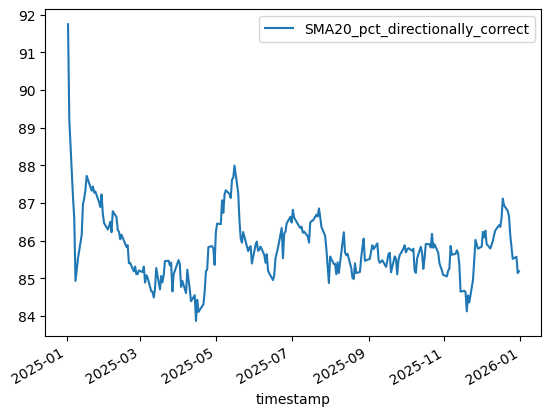

In [40]:
import matplotlib.pyplot as plt

daily_market_avgs.set_index('timestamp')[['SMA20_pct_directionally_correct']].plot()
plt.show()

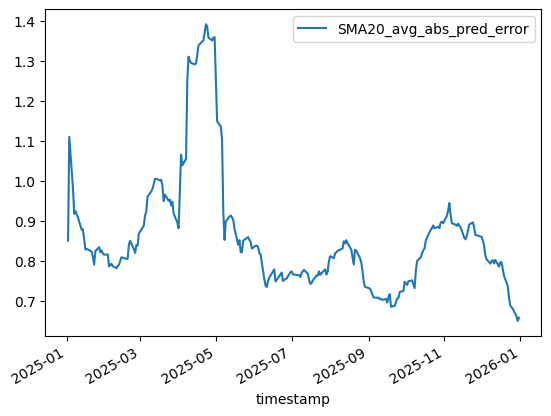

In [38]:
import matplotlib.pyplot as plt

daily_market_avgs.set_index('timestamp')[['SMA20_avg_abs_pred_error']].plot()
plt.show()